# Titanic Exercise

to install seaborn :
```bash
conda install -c conda-forge seaborn
````


In [111]:
import pandas as pd
from seaborn import load_dataset
import matplotlib.pyplot as plt
import numpy as np

In [112]:
embarked_labels = {
  "C": "Cherbourg",
  "Q": "Queenstown",
  "S": "Southampton",
}

In [113]:
# 1. Load the dataset
titanic = load_dataset("titanic")
titanic


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [114]:
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [115]:
# 2. Data cleaning
# 2.1. Check the missing values
print(titanic.shape)
print(titanic.isnull().sum())

# 2.2. Replace the missing values in age with the mean
# titanic["age"].fillna(titanic["age"].mean(), inplace=True)
titanic.dropna(subset=["age"], inplace=True)
titanic

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [116]:
# 3 Analyse data
# 3.1 Calculer le taux global de survie des passagers du Titanic
survival_rate = titanic.loc[titanic.survived == 1].survived.count() / len(titanic)
survival_rate = titanic.survived.sum() / titanic.survived.count()
survival_rate = titanic.survived.mean()
survival_rate = titanic.survived.value_counts(normalize=True)
survival_rate

survived
0    0.593838
1    0.406162
Name: proportion, dtype: float64

In [117]:
# Analyser la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked).
class_distrib = titanic.groupby("pclass").pclass.count() / titanic.pclass.count()
class_distrib = titanic["pclass"].value_counts(normalize=True)
class_distrib

pclass
3    0.497199
1    0.260504
2    0.242297
Name: proportion, dtype: float64

In [118]:
port_distrib = titanic["embarked"].value_counts(normalize=True)
port_distrib

embarked
S    0.778090
C    0.182584
Q    0.039326
Name: proportion, dtype: float64

In [119]:
passenger_distribution = titanic.pivot_table(values="survived", index="class", columns="embark_town", aggfunc="count", fill_value=0, observed=False)
passenger_distribution_pct = ((passenger_distribution / passenger_distribution.sum().sum()) * 100).round(2)
passenger_distribution_pct["total"] = passenger_distribution_pct.sum(axis=1)
passenger_columns = passenger_distribution_pct.sum(axis=0)
passenger_distribution_pct.loc["total"] = passenger_columns
passenger_distribution_pct

embark_town,Cherbourg,Queenstown,Southampton,total
class,,,,
First,10.39,0.28,15.17,25.84
Second,2.11,0.28,21.91,24.30
Third,5.76,3.37,40.73,49.86
total,18.26,3.93,77.81,100.00


In [120]:
passenger_distribution = titanic.groupby(["class", "embark_town"]).pclass.count().unstack()
display(passenger_distribution)

/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_8364/1241792097.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  passenger_distribution = titanic.groupby(["class", "embark_town"]).pclass.count().unstack()


embark_town,Cherbourg,Queenstown,Southampton
class,,,
First,74,2,108
Second,15,2,156
Third,41,24,290


In [121]:
# 3.2 Calculer la proportion de passagers masculins et féminins
gender_proportion = titanic.sex.groupby(titanic.sex).count() / titanic.sex.count()
gender_proportion = titanic.sex.value_counts(normalize=True)
gender_proportion

sex
male      0.634454
female    0.365546
Name: proportion, dtype: float64

<Axes: xlabel='age'>

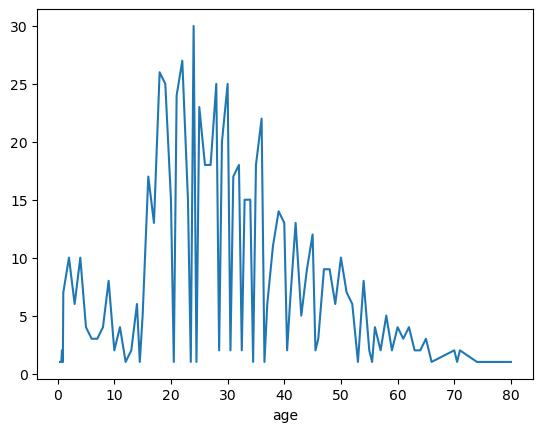

In [122]:
# 3.3 Identifier la distribution d'âge des passagers et trouver les catégories d'âge les plus représentées. (look pd.cut() function with bins)
age_distribution = titanic.age.value_counts()
age_distribution.sort_index().plot()

In [123]:
bins = [0, 2, 18, 35, 55, 65, 90]
labels = ["bébé", "enfant", "jeune adulte", "adulte", "senior", "mourant"]

avec_bins = pd.cut(titanic.age, bins=bins, labels=labels)
# distribution_age = avec_bins.value_counts()

titanic["age_category"] = avec_bins
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_category
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,jeune adulte
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,adulte
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,jeune adulte
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,jeune adulte
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,jeune adulte
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,female,39.0,0,5,29.1250,Q,Third,woman,False,NaN,Queenstown,no,False,adulte
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,jeune adulte
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,jeune adulte
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,jeune adulte


<Axes: xlabel='age_category'>

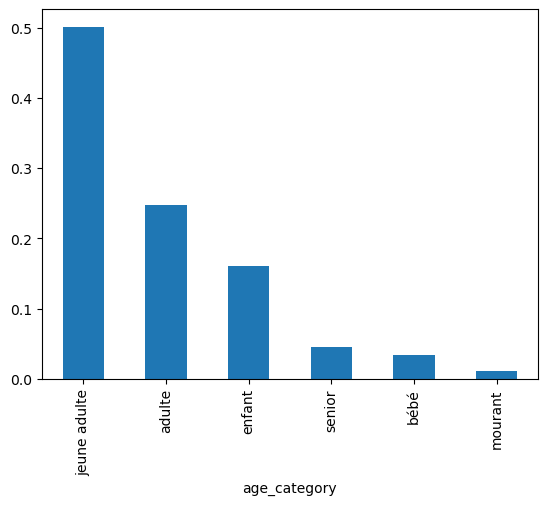

In [124]:
titanic.age_category.value_counts(normalize=True).plot(kind="bar")

<Axes: xlabel='pclass'>

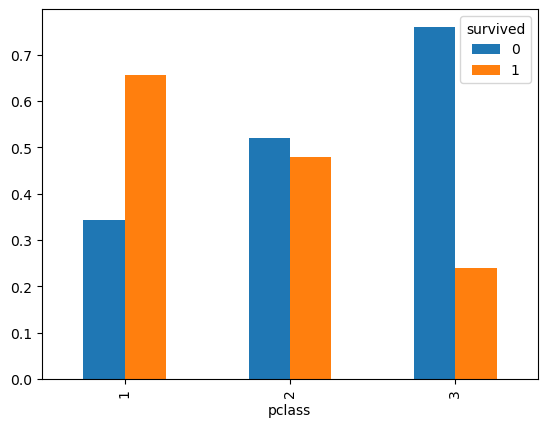

In [125]:
# 4 Alives analyse
# 4.1 Analyser la survie en fonction de la classe des billets (Pclass).

class_survived = titanic.pclass.groupby([titanic.pclass, titanic.survived]).count() / titanic.pclass.groupby(titanic.pclass).count()
class_survived = titanic.groupby("pclass").survived.value_counts(normalize=True)
class_survived.unstack().plot(kind="bar")

array([<Axes: ylabel='0'>, <Axes: ylabel='1'>], dtype=object)

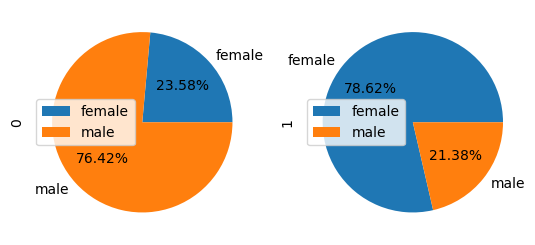

In [126]:
# 4.2 Examiner la survie en fonction du genre (Sex) des passagers.

titanic.groupby("sex").survived.value_counts(normalize=True).unstack().plot(kind="pie", subplots=True, autopct="%.2f%%")

<Axes: xlabel='pclass,sex'>

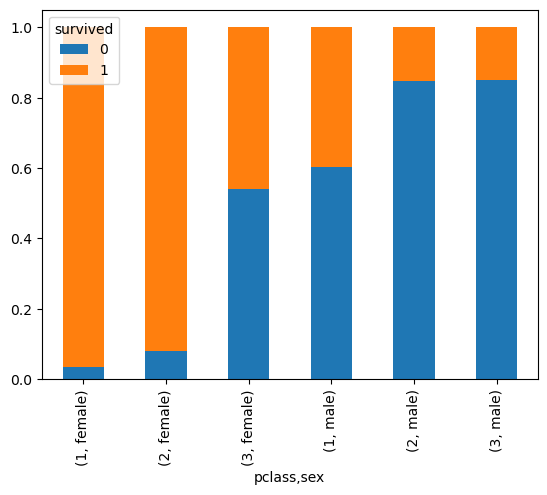

In [127]:
titanic.groupby(["pclass", "sex"]).survived\
  .value_counts(normalize=True).unstack()\
  .sort_index(level=[1], ascending=[True])\
  .plot.bar(stacked=True)

In [128]:
# 4.3 Étudier la survie en fonction de l'âge (Age) des passagers.

titanic.groupby("age_category").survived.value_counts(normalize=True).unstack()

/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_8364/1963593833.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic.groupby("age_category").survived.value_counts(normalize=True).unstack()


survived,0,1
age_category,,
bébé,0.375000,0.625000
enfant,0.521739,0.478261
jeune adulte,0.617318,0.382682
adulte,0.598870,0.401130
senior,0.656250,0.343750
mourant,0.875000,0.125000


In [129]:
# 4.4 Analyser la survie en fonction du port d'embarquement (Embarked).

titanic.groupby("embarked").survived.value_counts(normalize=True).unstack()

survived,0,1
embarked,,
C,0.392308,0.607692
Q,0.714286,0.285714
S,0.637184,0.362816


<Axes: title={'center': 'Titanic survival distribution'}, xlabel='survived', ylabel='# passengers'>

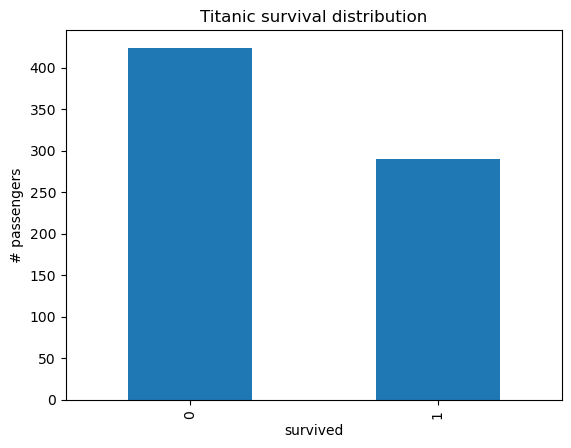

In [130]:
# 5 Plottings
# 5.1 Créer un diagramme à barres (plt.bar) pour visualiser le taux de survie global.

titanic.survived.value_counts().plot(kind="bar", title="Titanic survival distribution", ylabel="# passengers")

# survival_rate = titanic.alive.value_counts(normalize=True)
# plt.figure(figsize=(6, 7))
# plt.bar(survival_rate.index.astype(str), survival_rate.values)
# plt.xlabel("survived")
# plt.ylabel("# passengers")
# plt.title("Titanic survived distribution")
# plt.show()

pclass,1,2,3
embarked,,,
Q,0.071429,0.071429,0.857143
C,0.569231,0.115385,0.315385
S,0.194946,0.281588,0.523466


<Axes: xlabel='embarked'>

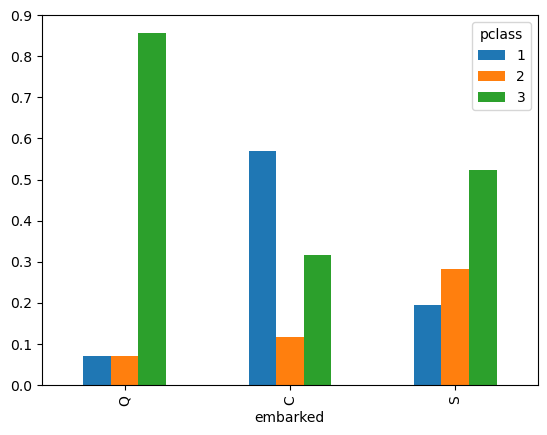

In [131]:
# 5.2 Générer un graphique en barres (plt.bar) pour montrer la répartition des passagers par classe (Pclass) et par port d'embarquement (Embarked). (laisser le pour la fin)

embarked_class = titanic.groupby(["embarked"]).pclass.value_counts(normalize=True).unstack().loc[["Q", "C", "S"], :]
display(embarked_class)
embarked_class.plot.bar()

embarked,C,Q,S
pclass,,,
1,74,2,108
2,15,2,156
3,41,24,290


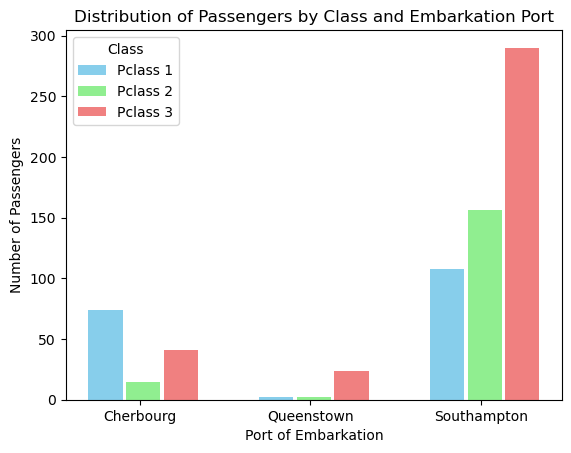

In [132]:
distribution_by_class_embarked = titanic.groupby(['pclass', 'embarked']).size().unstack()
display(distribution_by_class_embarked)

fig, ax = plt.subplots()
width = 0.2
class_labels: list[str] = distribution_by_class_embarked.columns.map(embarked_labels.get)
enu: list[tuple[int, tuple[int, str]]] = enumerate(zip(distribution_by_class_embarked.index, ["skyblue", "lightgreen", "lightcoral"]))
for i, (pclass, color) in enu:
  positions: list[int|float] = list(range(len(class_labels))) if i==0 else [pos + width + (0.02) for i, pos in enumerate(positions)]
  plt.bar(positions, distribution_by_class_embarked.loc[pclass], width=width, label=f'Pclass {pclass}', color=color)

# Adding labels and title
plt.title('Distribution of Passengers by Class and Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')
plt.xticks([pos + width for pos in range(len(class_labels))], class_labels)
plt.legend(title='Class')

# Show the plot
plt.show()

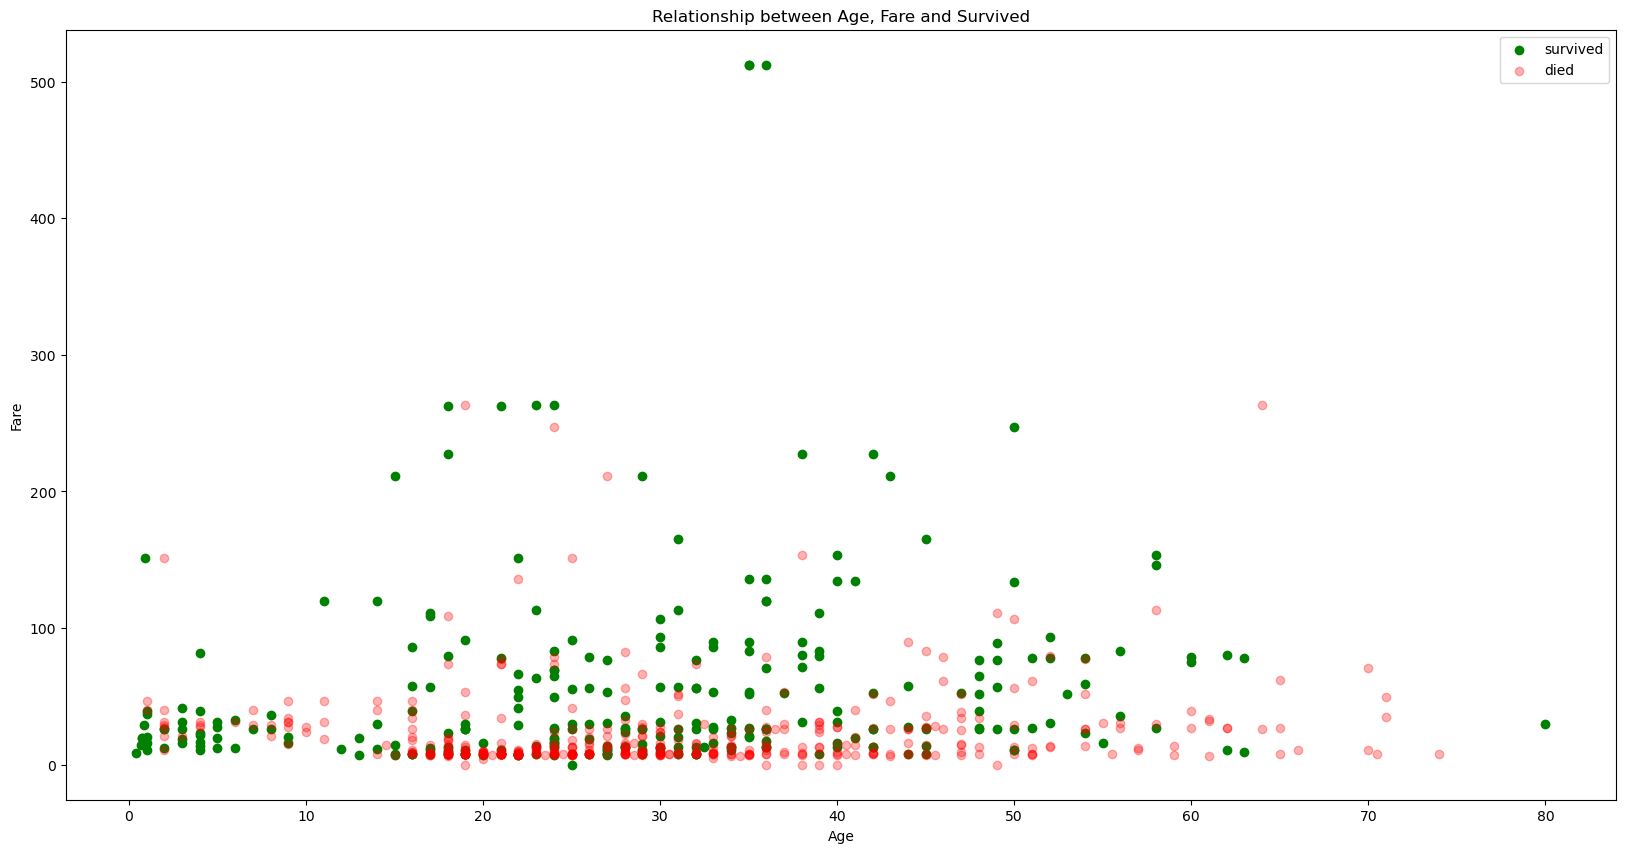

In [133]:
# 5.3 Créer un nuage de points (plt.scatter) pour représenter la relation entre l'âge (Age) et le prix du billet (Fare) en fonction de la survie.

survived_passengers = titanic.loc[titanic.survived == 1]
died_passengeres = titanic.loc[titanic.survived == 0]

plt.figure(figsize=(20, 10))

plt.scatter(
  survived_passengers.age, survived_passengers.fare,
  c="g", alpha=1, label="survived"
)
plt.scatter(
  died_passengeres.age, died_passengeres.fare,
  c="r", alpha=0.3, label="died"
)

plt.legend()
plt.title("Relationship between Age, Fare and Survived")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

/var/folders/9m/mdxclk9x25z0_ny0wr9rt4n80000gn/T/ipykernel_8364/583583986.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


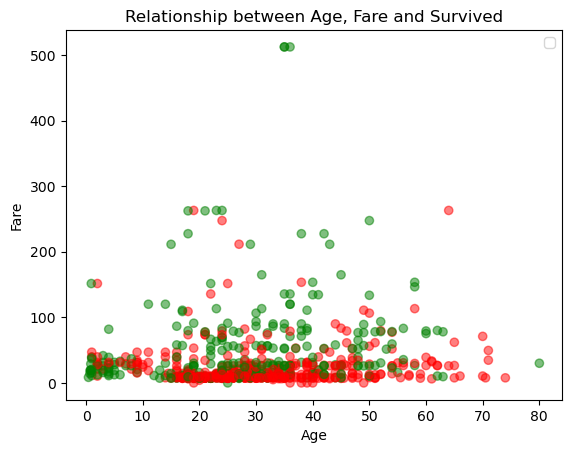

In [134]:
# 5.3 Créer un nuage de points (plt.scatter) pour représenter la relation entre l'âge (Age) et le prix du billet (Fare) en fonction de la survie.

plt.scatter(
  titanic.age,
  titanic.fare,
  c=titanic.survived.map(lambda s: "g" if s==1 else "r"),
  # labels=["Died", "Survived"],
  alpha=0.5
)

plt.legend()
plt.title("Relationship between Age, Fare and Survived")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

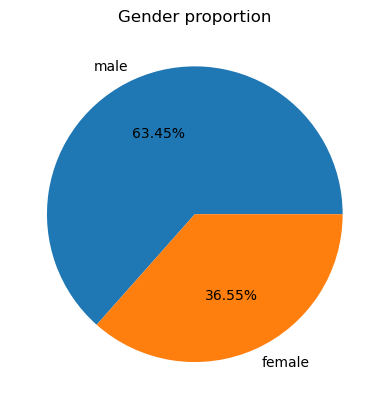

In [135]:
# 5.4 Produire un diagramme circulaire (Pie chart) pour montrer la proportion de passagers masculins et féminins

gender_proportion = titanic.sex.value_counts()
# titanic.sex.value_counts().plot(kind="pie", autopct="%.2f%%")

plt.pie(gender_proportion, labels=gender_proportion.index, autopct="%.2f%%")
plt.title("Gender proportion")
plt.show()

,age,fare,pclass,sibsp,parch,survived,gender
age,1.000000,0.096067,-0.369226,-0.308247,-0.189119,-0.077221,-0.093254
fare,0.096067,1.000000,-0.554182,0.138329,0.205119,0.268189,0.184994
pclass,-0.369226,-0.554182,1.000000,0.067247,0.025683,-0.359653,-0.155460
sibsp,-0.308247,0.138329,0.067247,1.000000,0.383820,-0.017358,0.103950
parch,-0.189119,0.205119,0.025683,0.383820,1.000000,0.093317,0.246972
survived,-0.077221,0.268189,-0.359653,-0.017358,0.093317,1.000000,0.538826
gender,-0.093254,0.184994,-0.155460,0.103950,0.246972,0.538826,1.000000


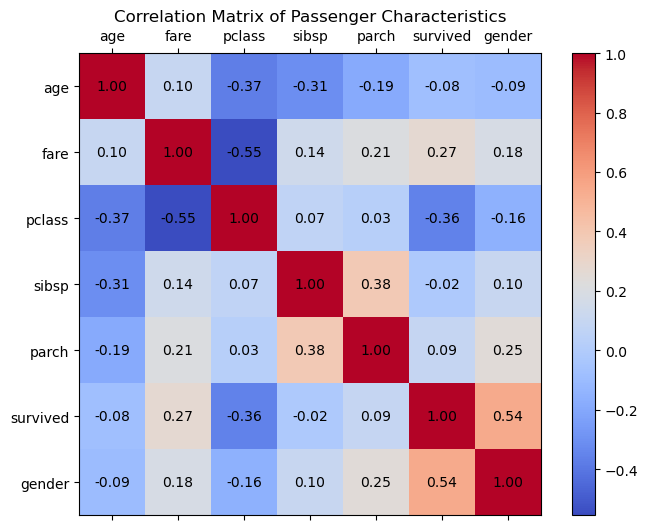

In [136]:
# 6 Bonus for the datascients experts ;P

# 6.1 Examine the correlation between different passenger characteristics to identify meaningful relationships.
# Select relevant columns for correlation analysis
correlation_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']
titanic['gender'] = titanic['sex'].map({'male': 0, 'female': 1})
# Create a correlation matrix
correlation_matrix = titanic[correlation_columns].corr()
display(correlation_matrix)

# Create a basic heatmap using Matplotlib
fig, ax = plt.subplots(figsize=(8, 6))
cax = ax.matshow(correlation_matrix, cmap='coolwarm')
fig.colorbar(cax)

# Set labels
ax.set_xticks(np.arange(len(correlation_columns)))
ax.set_yticks(np.arange(len(correlation_columns)))
ax.set_xticklabels(correlation_columns)
ax.set_yticklabels(correlation_columns)

# Display the correlation values
for i in range(len(correlation_columns)):
  for j in range(len(correlation_columns)):
    text = ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')

# Set title
plt.title('Correlation Matrix of Passenger Characteristics')

# Show the plot
plt.show()

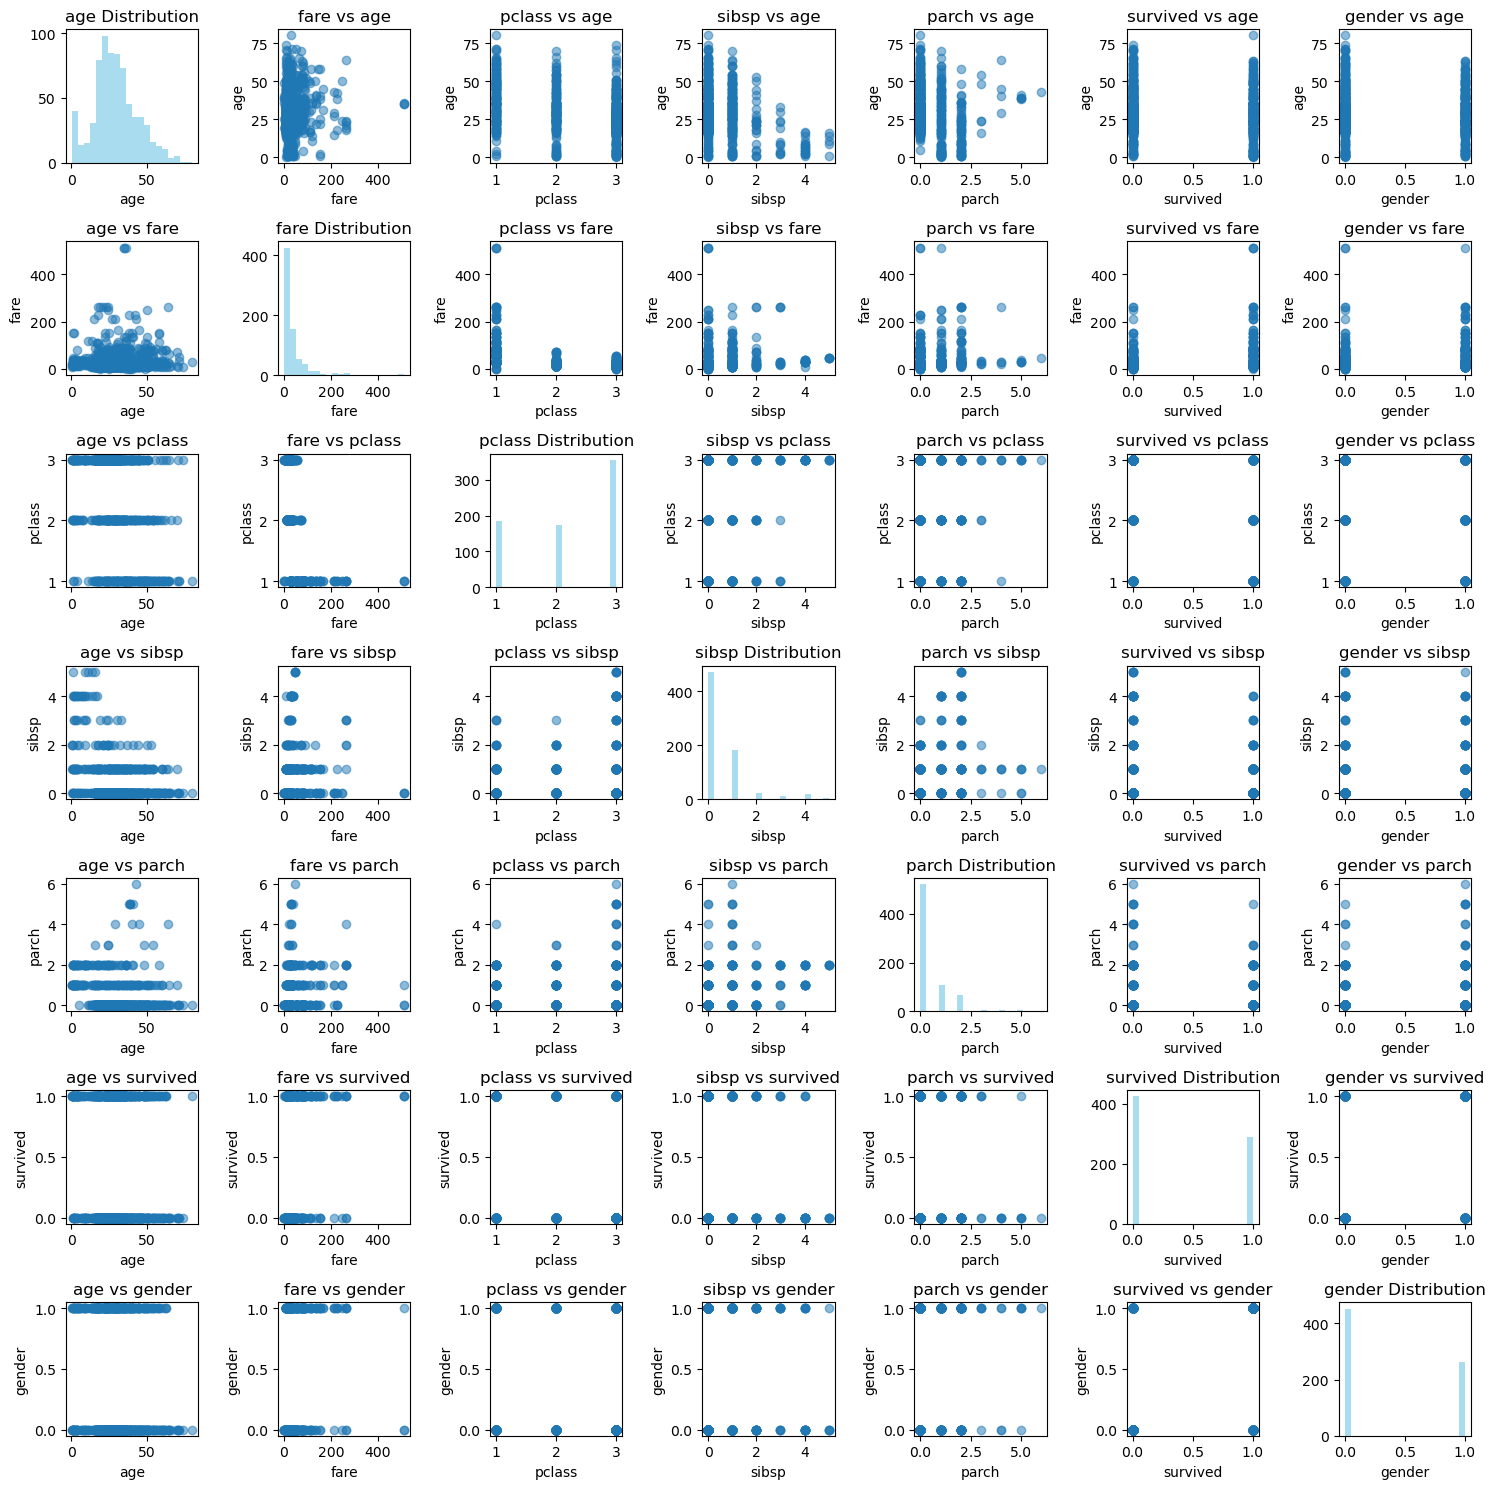

In [137]:
import numpy as np

# Select relevant numerical columns
numerical_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived', 'gender']

# Create a matrix of scatter plots
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=len(numerical_columns), figsize=(15, 15))

for i in range(len(numerical_columns)):
    for j in range(len(numerical_columns)):
        if i == j:
            axes[i, j].hist(titanic[numerical_columns[i]], bins=20, color='skyblue', alpha=0.7)
            axes[i, j].set_title(f'{numerical_columns[i]} Distribution')
            axes[i, j].set_xlabel(numerical_columns[i])
        else:
            axes[i, j].scatter(titanic[numerical_columns[j]], titanic[numerical_columns[i]], alpha=0.5)
            axes[i, j].set_title(f'{numerical_columns[j]} vs {numerical_columns[i]}')
            axes[i, j].set_xlabel(numerical_columns[j])
            axes[i, j].set_ylabel(numerical_columns[i])
            # a, b = np.polyfit(titanic[numerical_columns[j]], titanic[numerical_columns[i]], 1)
            # axes[i, j].plot(titanic[numerical_columns[j]], a*titanic[numerical_columns[j]]+b, c="r")
            # a, b = np.polyfit(titanic[numerical_columns[i]], titanic[numerical_columns[j]], 1)
            # axes[i, j].plot(titanic[numerical_columns[i]], a*titanic[numerical_columns[i]]+b, c="g")

# Adjust layout
plt.tight_layout()
plt.show()